In [1]:
import os
os.chdir(os.path.expanduser("~/ransomware_xai_project"))
print(f"Working directory: {os.getcwd()}")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
from lime.lime_tabular import LimeTabularExplainer

os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)

X_train = pd.read_csv("data/X_train_selected.csv", index_col=0)
X_test = pd.read_csv("data/X_test_selected.csv", index_col=0)
y_train = pd.read_csv("data/y_train.csv", index_col=0).squeeze()
y_test = pd.read_csv("data/y_test.csv", index_col=0).squeeze()

models = {
    'Decision Tree': joblib.load("models/dt_model.joblib"),
    'Random Forest': joblib.load("models/rf_model.joblib"),
    'XGBoost': joblib.load("models/xgb_model.joblib"),
    'Logistic Regression': joblib.load("models/lr_model.joblib"),
}

# Load EBM separately with wrapper
from interpret.glassbox import ExplainableBoostingClassifier
ebm_model = joblib.load("models/ebm_model.joblib")
models['EBM'] = ebm_model

# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Benign', 'Malware'],
    mode='classification',
    random_state=42
)

print(f"Data: Train {X_train.shape}, Test {X_test.shape}")
print(f"Models: {list(models.keys())}")
print("LIME explainer ready")

Working directory: /Users/saneeshghimire/ransomware_xai_project
Data: Train (46876, 20), Test (11720, 20)
Models: ['Decision Tree', 'Random Forest', 'XGBoost', 'Logistic Regression', 'EBM']
LIME explainer ready


In [5]:
print("=" * 60)
print("LIME ANALYSIS — ALL 5 MODELS (100 samples each)")
print("=" * 60)

known_features = X_train.columns.tolist()

def extract_feature_name(lime_expression, known_features):
    for feat in known_features:
        if feat in lime_expression:
            return feat
    return None

sample_indices = X_test.sample(100, random_state=42).index
lime_rankings = {}

for name, model in models.items():
    print(f"\nRunning LIME for {name}...")
    feature_weights = {}
    
    for idx in sample_indices:
        if name == 'EBM':
            def predict_fn(data):
                return model.predict_proba(pd.DataFrame(data, columns=X_train.columns.tolist()))
            exp = lime_explainer.explain_instance(
                X_test.loc[idx].values, predict_fn, num_features=10
            )
        else:
            exp = lime_explainer.explain_instance(
                X_test.loc[idx].values, model.predict_proba, num_features=10
            )
        
        for feat_expr, weight in exp.as_list():
            feat_name = extract_feature_name(feat_expr, known_features)
            if feat_name is None:
                continue
            feature_weights[feat_name] = feature_weights.get(feat_name, 0) + abs(weight)
    
    ranking = pd.DataFrame({
        'feature': list(feature_weights.keys()),
        'LIME_importance': list(feature_weights.values())
    }).sort_values('LIME_importance', ascending=False).reset_index(drop=True)
    
    lime_rankings[name] = ranking
    print(f"  {name} — Top 5:")
    for _, row in ranking.head(5).iterrows():
        print(f"    {row['feature']}: {row['LIME_importance']:.4f}")

print("\nLIME analysis complete for all models")

# ── RANKING COMPARISON TABLE ──
print("\n" + "=" * 70)
print("LIME FEATURE RANKING COMPARISON — ALL 5 MODELS")
print("=" * 70)

print(f"\n{'Rank':<6}{'DT':<30}{'EBM':<30}{'RF':<30}{'XGB':<30}{'LR':<30}")
print("-" * 156)
for r in range(1, 11):
    row = f"{r:<6}"
    for name in ['Decision Tree', 'EBM', 'Random Forest', 'XGBoost', 'Logistic Regression']:
        if r <= len(lime_rankings[name]):
            f = lime_rankings[name].iloc[r-1]['feature']
            row += f"{f:<30}"
        else:
            row += f"{'—':<30}"
    print(row)

combined = pd.DataFrame()
for name, rk in lime_rankings.items():
    t = rk[['feature','LIME_importance']].copy()
    t.columns = ['feature', f'LIME_{name}']
    if combined.empty:
        combined = t
    else:
        combined = combined.merge(t, on='feature', how='outer')
combined.to_csv("results/tables/lime_rankings_all_models.csv", index=False)
print("\nSaved to results/tables/lime_rankings_all_models.csv")

LIME ANALYSIS — ALL 5 MODELS (100 samples each)

Running LIME for Decision Tree...
  Decision Tree — Top 5:
    svcscan.process_services: 46.4272
    pslist.avg_handlers: 20.8246
    svcscan.nservices: 18.4523
    callbacks.ncallbacks: 12.5922
    dlllist.ndlls: 7.8291

Running LIME for Random Forest...
  Random Forest — Top 5:
    svcscan.nservices: 20.9832
    svcscan.process_services: 19.3038
    pslist.avg_handlers: 7.6336
    svcscan.kernel_drivers: 4.3756
    malfind.commitCharge: 4.2841

Running LIME for XGBoost...
  XGBoost — Top 5:
    svcscan.process_services: 44.2620
    svcscan.nservices: 28.7358
    pslist.avg_handlers: 11.7382
    malfind.commitCharge: 11.0550
    pslist.avg_threads: 9.5614

Running LIME for Logistic Regression...
  Logistic Regression — Top 5:
    svcscan.process_services: 52.4361
    svcscan.nservices: 28.2829
    ldrmodules.not_in_load: 23.1217
    pslist.avg_threads: 11.9244
    handles.nmutant: 10.8915

Running LIME for EBM...
  EBM — Top 5:
    svcs

Generating LIME visual explanation for one sample...


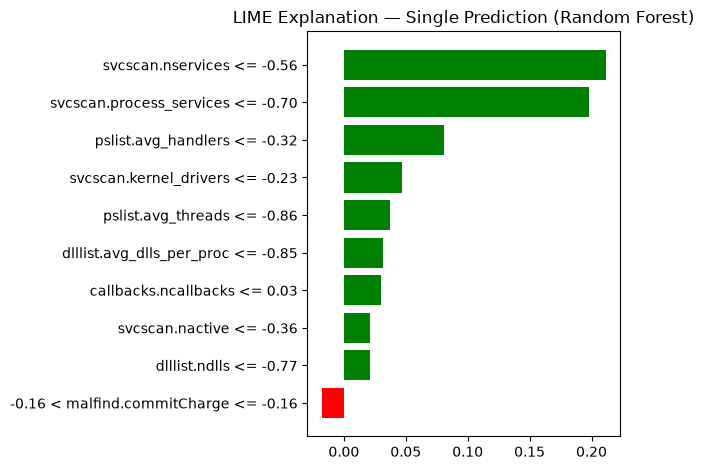

Actual=1, Predicted=1 — CORRECT
HTML saved: results/figures/lime_explanation_example.html


In [6]:
print("Generating LIME visual explanation for one sample...")

# Explain one sample with Random Forest
exp = lime_explainer.explain_instance(
    X_test.iloc[0].values,
    models['Random Forest'].predict_proba,
    num_features=10
)

# Save as HTML
exp.save_to_file("results/figures/lime_explanation_example.html")

# Also plot it
fig = exp.as_pyplot_figure()
plt.title("LIME Explanation — Single Prediction (Random Forest)")
plt.tight_layout()
plt.savefig("results/figures/lime_explanation_RF.png", dpi=300, bbox_inches='tight')
plt.show()

actual = y_test.iloc[0]
pred = models['Random Forest'].predict(X_test.iloc[[0]])[0]
print(f"Actual={actual}, Predicted={pred} — {'CORRECT' if actual==pred else 'INCORRECT'}")
print("HTML saved: results/figures/lime_explanation_example.html")

In [7]:
from scipy.stats import spearmanr

print("=" * 70)
print("SHAP vs LIME CROSS-METHOD CONSISTENCY")
print("=" * 70)

# Load SHAP rankings
shap_csv = pd.read_csv("results/tables/shap_rankings_all_models.csv")

consistency_results = []

for name in ['Decision Tree', 'EBM', 'Random Forest', 'XGBoost', 'Logistic Regression']:
    shap_col = f'SHAP_{name}'
    
    # Get SHAP ranking for this model
    shap_rank = shap_csv[['feature', shap_col]].dropna().sort_values(shap_col, ascending=False)
    shap_rank['shap_rank'] = range(1, len(shap_rank) + 1)
    
    # Get LIME ranking for this model (now clean — no numeric artefacts)
    lime_rank = lime_rankings[name].copy()
    lime_rank['lime_rank'] = range(1, len(lime_rank) + 1)
    
    # Merge on feature name
    merged = shap_rank[['feature', 'shap_rank']].merge(
        lime_rank[['feature', 'lime_rank']], on='feature', how='inner'
    )
    
    if len(merged) >= 3:
        rho, pval = spearmanr(merged['shap_rank'], merged['lime_rank'])
        
        # Top-5 and Top-10 overlap
        shap_top5 = set(shap_rank.head(5)['feature'])
        lime_top5 = set(lime_rank.head(5)['feature'])
        overlap5 = len(shap_top5 & lime_top5)
        
        shap_top10 = set(shap_rank.head(10)['feature'])
        lime_top10 = set(lime_rank.head(10)['feature'])
        overlap10 = len(shap_top10 & lime_top10)
        
        consistency_results.append({
            'Model': name,
            'Spearman_rho': round(rho, 3),
            'p_value': round(pval, 4),
            'Top5_overlap': f"{overlap5}/5 ({overlap5*20}%)",
            'Top10_overlap': f"{overlap10}/10 ({overlap10*10}%)",
            'N_features_matched': len(merged),
            'Agreement': 'Excellent' if rho > 0.9 else ('Strong' if rho > 0.7 else ('Moderate' if rho > 0.5 else 'Weak'))
        })
        print(f"\n{name}:")
        print(f"  Spearman rho = {rho:.3f} (p = {pval:.4f})")
        print(f"  Top-5 overlap  = {overlap5}/5 ({overlap5*20}%)")
        print(f"  Top-10 overlap = {overlap10}/10 ({overlap10*10}%)")
        print(f"  Features matched = {len(merged)}")
        print(f"  Agreement: {'Excellent' if rho > 0.9 else ('Strong' if rho > 0.7 else ('Moderate' if rho > 0.5 else 'Weak'))}")
    else:
        print(f"\n{name}: Not enough matching features for correlation")

# Save consistency results
cons_df = pd.DataFrame(consistency_results)
cons_df.to_csv("results/tables/shap_lime_consistency.csv", index=False)

print(f"\n{'='*70}")
print("CONSISTENCY TABLE:")
print(cons_df.to_string(index=False))
print(f"\nSaved to results/tables/shap_lime_consistency.csv")
print("LIME + CONSISTENCY ANALYSIS COMPLETE")

SHAP vs LIME CROSS-METHOD CONSISTENCY

Decision Tree:
  Spearman rho = 0.861 (p = 0.0000)
  Top-5 overlap  = 4/5 (80%)
  Top-10 overlap = 9/10 (90%)
  Features matched = 19
  Agreement: Strong

EBM:
  Spearman rho = 0.618 (p = 0.0082)
  Top-5 overlap  = 3/5 (60%)
  Top-10 overlap = 7/10 (70%)
  Features matched = 17
  Agreement: Moderate

Random Forest:
  Spearman rho = 0.598 (p = 0.0068)
  Top-5 overlap  = 4/5 (80%)
  Top-10 overlap = 7/10 (70%)
  Features matched = 19
  Agreement: Moderate

XGBoost:
  Spearman rho = 0.870 (p = 0.0000)
  Top-5 overlap  = 3/5 (60%)
  Top-10 overlap = 9/10 (90%)
  Features matched = 19
  Agreement: Strong

Logistic Regression:
  Spearman rho = 0.961 (p = 0.0000)
  Top-5 overlap  = 5/5 (100%)
  Top-10 overlap = 10/10 (100%)
  Features matched = 17
  Agreement: Excellent

CONSISTENCY TABLE:
              Model  Spearman_rho  p_value Top5_overlap Top10_overlap  N_features_matched Agreement
      Decision Tree         0.861   0.0000    4/5 (80%)    9/10 (90